# FILL NULLS IN ENVIRONMENTAL DATA

In [120]:
import sys
print(sys.executable)

/usr/bin/python


In [121]:
#we import all they key libraries needed in this notebook
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib as matplotlib

In [122]:
#this is a function from another notebook originally, but the code is basically the same and allows us to see the data on a map
def plotColsOnMap(cols,df):
    #the index is reset from using lat and lon just in case
    df_reset = df.reset_index()

    #the number of rows varies depending on the number of columns to plot
    rows = (len(cols)//2) + (len(cols)%2==1)

    #a set of subplots is created
    fig, axes = plt.subplots(nrows=rows, ncols=2, figsize=(20, rows*4), subplot_kw={"projection": ccrs.PlateCarree()})

    #we plot each column
    axes = axes.flatten()
    for i, col in enumerate(cols):
        ax = axes[i]#subplot

        #we want to see the coastlines on the globe and only take not null values
        ax.add_feature(cfeature.COASTLINE)
        valid_data = df_reset[df_reset[col].notna()]

        #scatter plot is created
        sc = ax.scatter(
            valid_data["LONGITUDE"],
            valid_data["LATITUDE"],
            c=valid_data[col],
            cmap="viridis",
            s=40,
            transform=ccrs.PlateCarree(),
        )

        #we want to see the entire globe and not just the values 
        ax.set_xlim(-180,180)
        ax.set_ylim(-90,90)

        plt.colorbar(sc, ax=ax, label="color scale")
        ax.set_title(col)

    plt.tight_layout()
    plt.show()

In [123]:
env_df = pd.read_csv("./csv/features/env_data.csv") 
env_df = env_df.drop(columns=['Unnamed: 0'])
print(env_df.columns)
env_df.info()

Index(['LATITUDE', 'LONGITUDE', 'O2', 'T', 'N', 'P'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40567 entries, 0 to 40566
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LATITUDE   40567 non-null  float64
 1   LONGITUDE  40567 non-null  float64
 2   O2         29299 non-null  float64
 3   T          39233 non-null  float64
 4   N          13293 non-null  float64
 5   P          18583 non-null  float64
dtypes: float64(6)
memory usage: 1.9 MB


In [124]:
data_cols = ['O2', 'T', 'N', 'P']
cor_cols = ['LATITUDE', 'LONGITUDE']

In [125]:
env_df.describe()

,LATITUDE,LONGITUDE,O2,T,N,P
count,40567.000000,40567.000000,29299.000000,39233.000000,13293.000000,18583.000000
mean,-1.241107,-9.319792,260.462001,14.505559,5.452691,0.566445
std,47.353145,109.922728,56.796003,11.053765,8.164558,0.553473
min,-78.000000,-180.000000,102.856000,-2.107167,0.000000,0.000000
25%,-42.000000,-110.000000,207.591500,3.016500,0.108000,0.146500
50%,-8.000000,-18.000000,245.734833,16.328500,1.073000,0.338333
75%,34.000000,86.000000,311.393083,25.470833,7.250167,0.822167
max,90.000000,180.000000,460.109000,29.839667,34.059333,3.137833


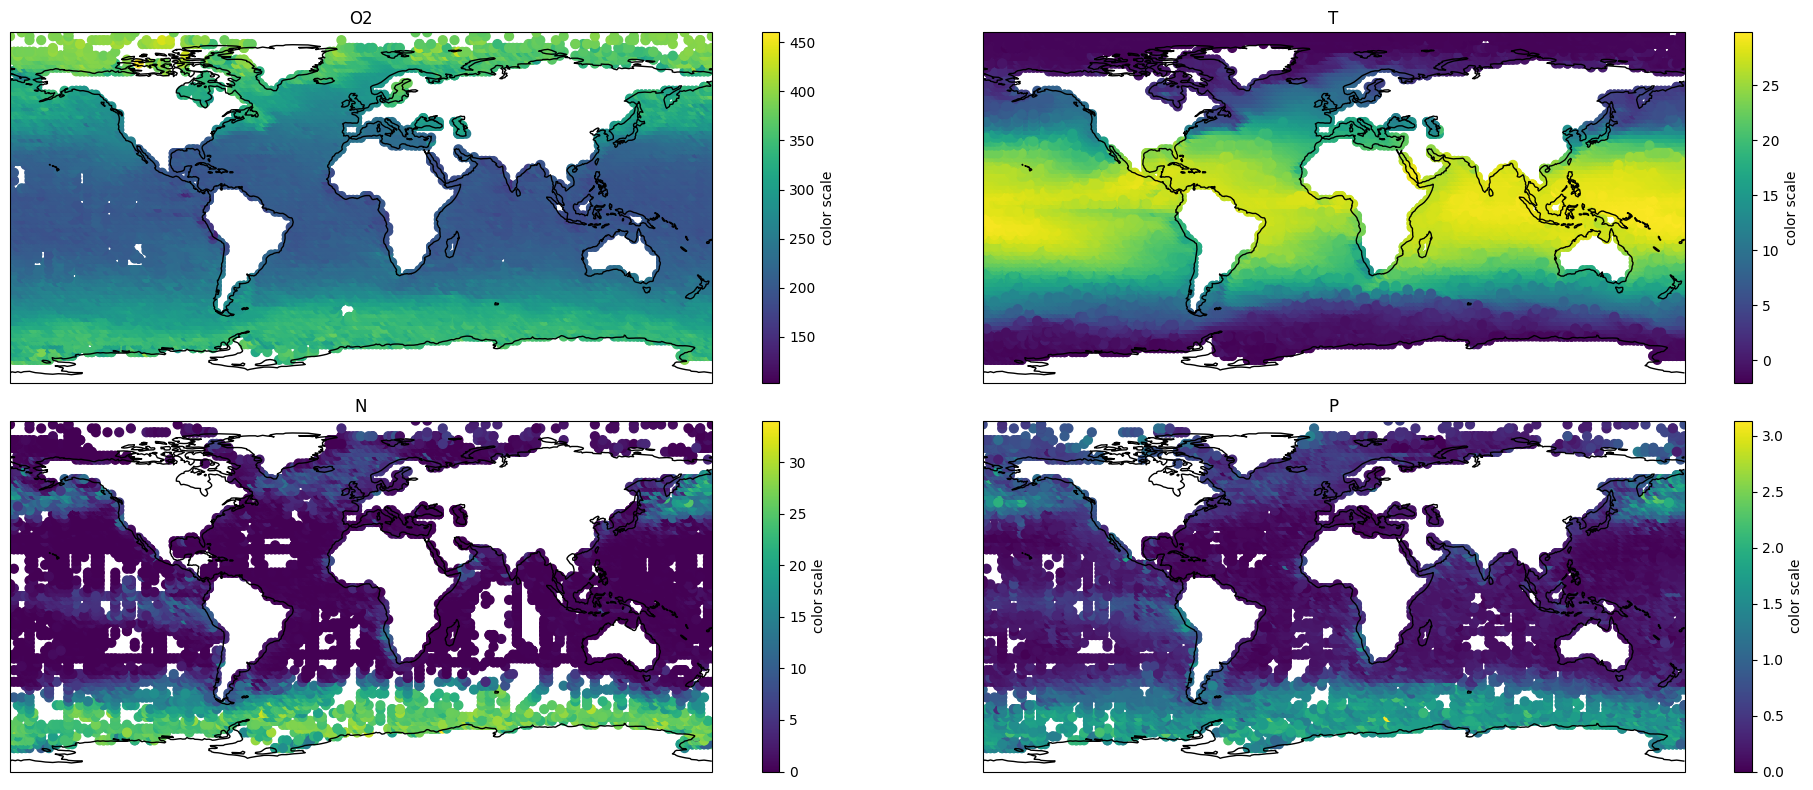

In [126]:
plotColsOnMap(data_cols, env_df)

## Simple fill
The first strategy is to use mean value for each column to fill the missing data.

In [127]:
#we create a dictionary with mean value for each column name
means = dict(env_df.mean())

In [128]:
#we fill values and see the results in info
env_simple_fill = env_df.fillna(value=means)
env_simple_fill.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40567 entries, 0 to 40566
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LATITUDE   40567 non-null  float64
 1   LONGITUDE  40567 non-null  float64
 2   O2         40567 non-null  float64
 3   T          40567 non-null  float64
 4   N          40567 non-null  float64
 5   P          40567 non-null  float64
dtypes: float64(6)
memory usage: 1.9 MB


In [129]:
#I saved the results
env_simple_fill.to_csv("./csv/filled/env_data_simple_fill.csv", index=False)

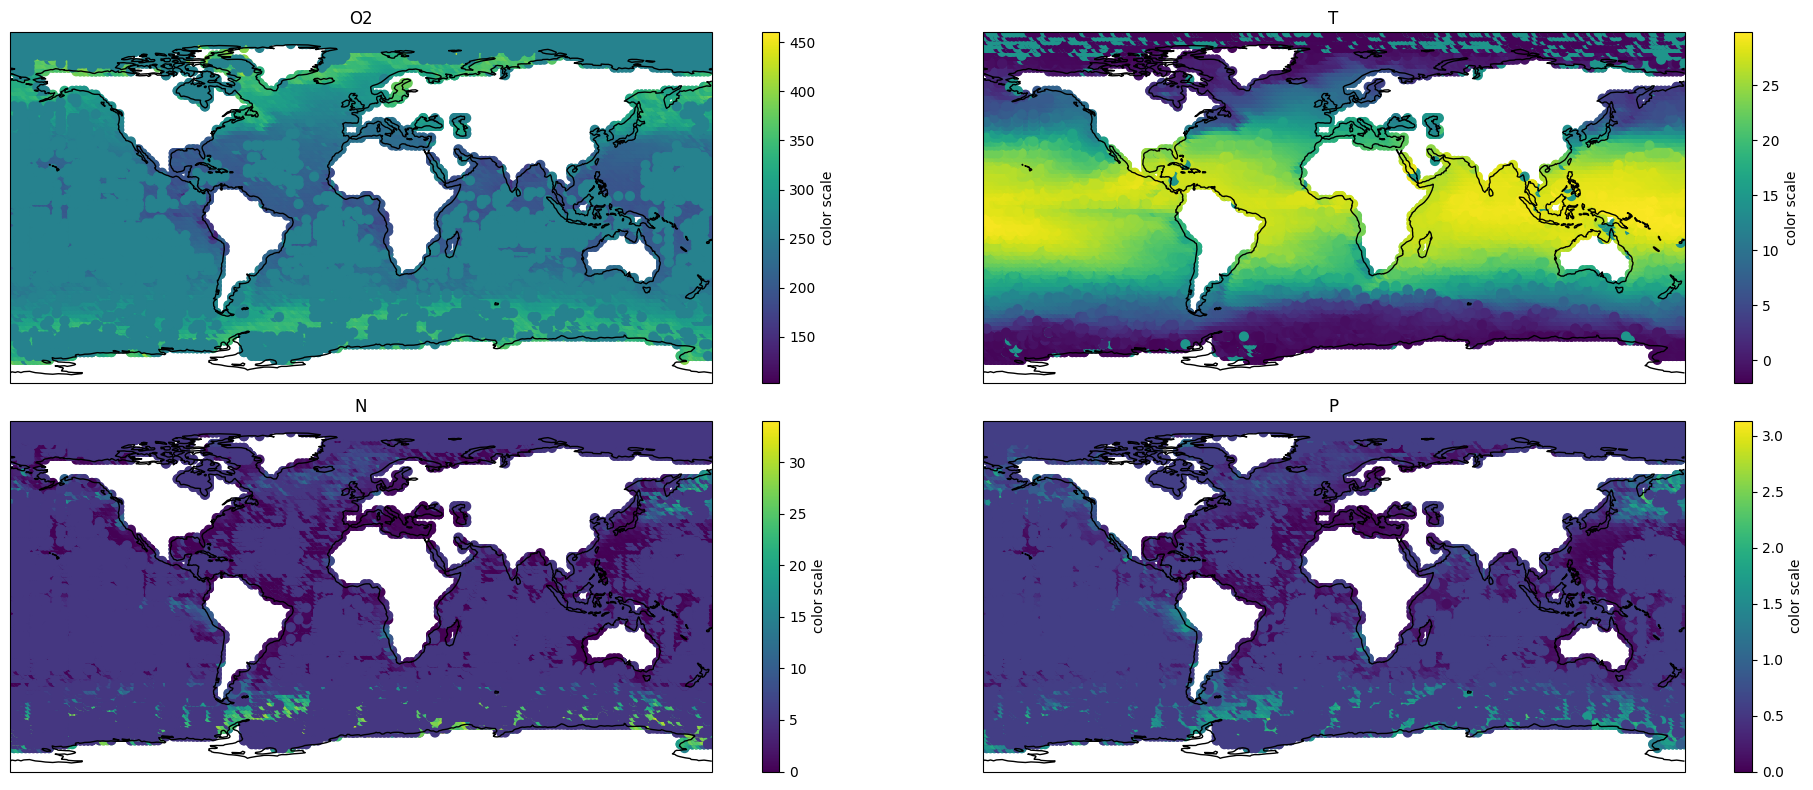

In [130]:
#here the imputed values can be clearly seen on the map
plotColsOnMap(data_cols, env_simple_fill)

## Complex fill
In this part I aimed to use coordinates in order to figure out what the best missing value might be.

### Latitude average
The first approach I wanted to try was Latitude based average. So, instead of taking the average of the entire planet, which can yield inaccurate results, we only use points on the same latitude. 

I think this can be quite good as the initial data clearly varies a lot based on latitude and thus, latitude is an important factor that should be accounted for when filling in the gaps.

In [131]:
avg_cols = []

for col in data_cols:
    avg_col = env_df.groupby('LATITUDE')[col].transform(
        lambda x: x.fillna(x.mean())
    )
    avg_cols.append(avg_col)

env_lat_fill = pd.concat([env_df[cor_cols]]+avg_cols, axis=1)

env_lat_fill.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40567 entries, 0 to 40566
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LATITUDE   40567 non-null  float64
 1   LONGITUDE  40567 non-null  float64
 2   O2         40567 non-null  float64
 3   T          40567 non-null  float64
 4   N          40567 non-null  float64
 5   P          40567 non-null  float64
dtypes: float64(6)
memory usage: 1.9 MB


As we can see this method is not that computationally intensive, but manages to produce way better results overall.

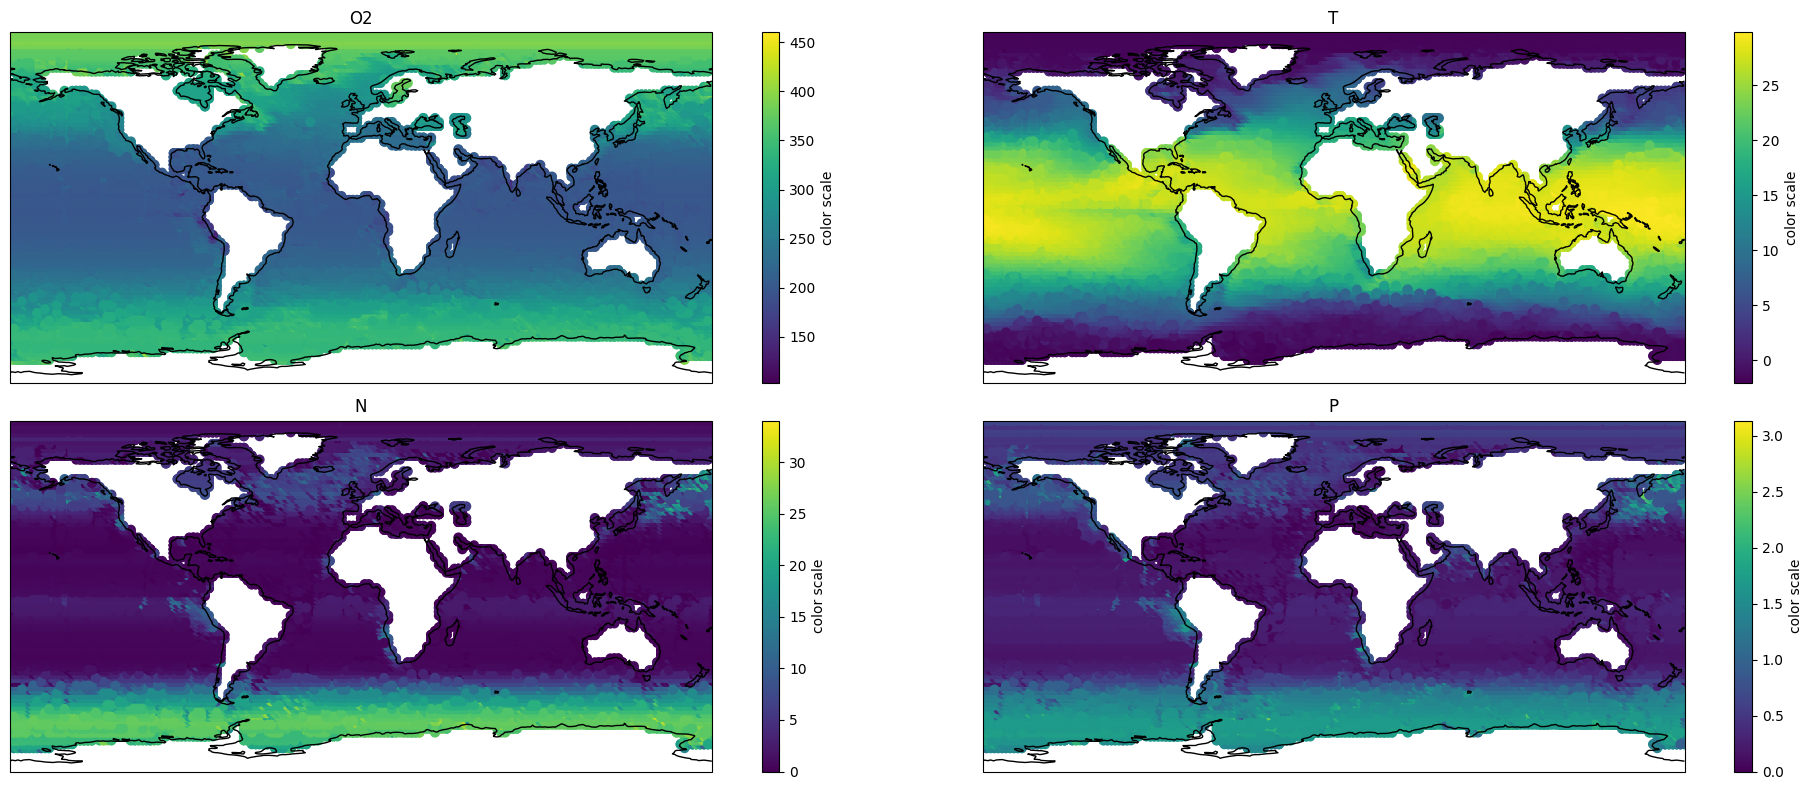

In [132]:
plotColsOnMap(data_cols, env_lat_fill)

In [133]:
env_lat_fill.to_csv("./csv/filled/env_data_lat_fill.csv", index=False)